20:33:07 - cmdstanpy - INFO - Chain [1] start processing


[INFO] Dataset: 365 daily observations
[INFO] Date range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00
[INFO] Train: 335 days, Test: 30 days


20:33:07 - cmdstanpy - INFO - Chain [1] done processing



[RESULTS] Holdout MAE: 9.1655, RMSE: 12.3549
[RESULTS] CV MAE mean: 7.8877, CV RMSE mean: 9.8099

[RESULTS] All metrics: {'MAE_test': 9.165529212227739, 'RMSE_test': 12.354884385456641, 'horizon_days': 30, 'train_size': 335, 'test_size': 30, 'CV_mae_mean': 7.887659814249767, 'CV_rmse_mean': 9.809914382016663, 'CV_folds': 3}


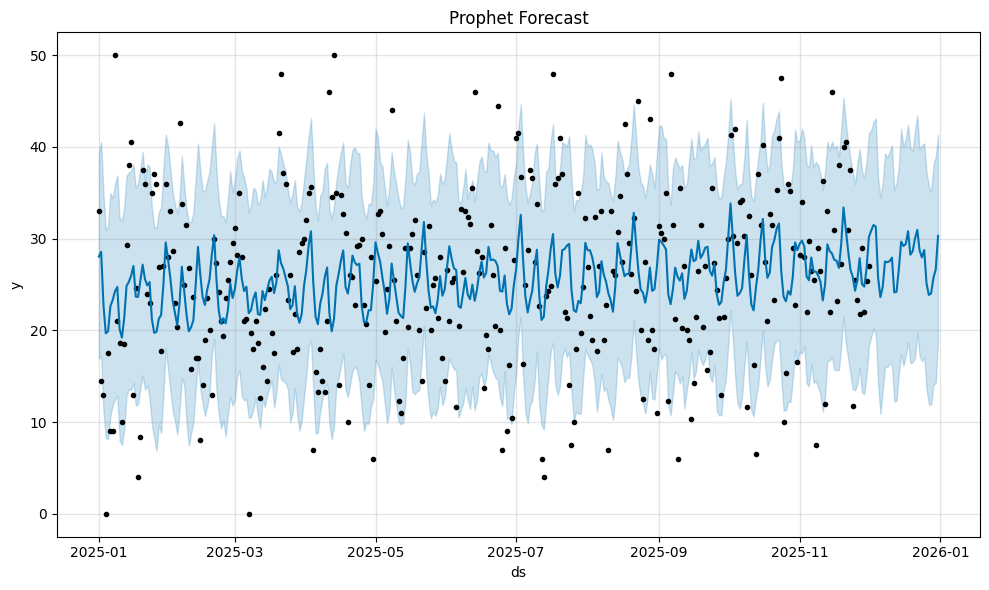

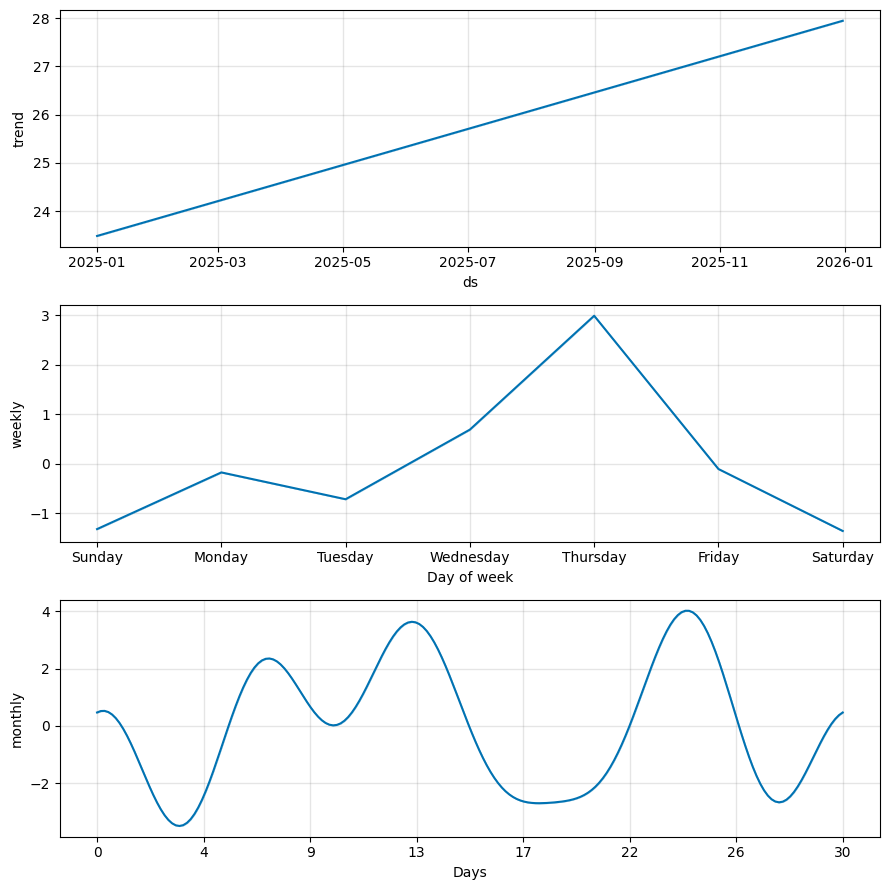


Forecast sauvegarde : c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\artifacts\prophet_forecast_final.csv
Metrics sauvegardees : c:\Users\richa\Prediction_de_vente\Prediction_de_vente\models\metrics\prophet_metrics_final.json


In [4]:
import pandas as pd
from pathlib import Path
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import json

PROJECT_ROOT = Path.cwd().parent
CLEAN_PATH = PROJECT_ROOT / "data" / "interim" / "sample_clean.csv"

FORECAST_PATH = PROJECT_ROOT / "models" / "artifacts" / "prophet_forecast_final.csv"
METRICS_PATH = PROJECT_ROOT / "models" / "metrics" / "prophet_metrics_final.json"

FORECAST_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)

# --- Load and prepare data ---
df = pd.read_csv(CLEAN_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
df_prophet = df.rename(columns={"date": "ds", "value": "y"})

# Handle duplicate dates by averaging
df_prophet = df_prophet.groupby("ds", as_index=False).agg({"y": "mean"})

# Enforce daily frequency with interpolation for gaps
df_prophet = df_prophet.set_index("ds").asfreq("D").interpolate(method="linear").reset_index()
assert df_prophet["ds"].is_unique, "Dates must be unique after aggregation"

print(f"[INFO] Dataset: {len(df_prophet)} daily observations")
print(f"[INFO] Date range: {df_prophet['ds'].min()} to {df_prophet['ds'].max()}")

# --- Train/Test split ---
horizon = 30
train_df = df_prophet.iloc[:-horizon].copy()
test_df = df_prophet.iloc[-horizon:].copy()

print(f"[INFO] Train: {len(train_df)} days, Test: {len(test_df)} days")

# --- Prophet model ---
# Determine dataset span to configure seasonality appropriately
n_days = (df_prophet['ds'].max() - df_prophet['ds'].min()).days

model = Prophet(
    growth="linear",
    weekly_seasonality=False,   # will add custom
    yearly_seasonality=False,   # will add custom if enough data
    changepoint_prior_scale=0.03,
    seasonality_prior_scale=5.0,
)

# Add weekly seasonality (always)
model.add_seasonality("weekly", period=7, fourier_order=5)

# Add monthly seasonality if at least 2 months of data
if n_days >= 60:
    model.add_seasonality("monthly", period=30.5, fourier_order=5)

# Add yearly seasonality only if data spans at least ~1.5 years
# (otherwise Prophet's cross-validation will warn about initial window)
if n_days >= 548:
    model.add_seasonality("yearly", period=365.25, fourier_order=10)

# --- Fit ---
model.fit(train_df)

# --- Forecast ---
future = model.make_future_dataframe(periods=horizon, freq="D")
forecast = model.predict(future)

# --- Evaluation on holdout ---
eval_df = test_df.merge(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='inner')
y_true = eval_df['y']
y_pred = eval_df['yhat']

mae_test = mean_absolute_error(y_true, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_true, y_pred))

metrics = {
    "MAE_test": float(mae_test),
    "RMSE_test": float(rmse_test),
    "horizon_days": horizon,
    "train_size": len(train_df),
    "test_size": len(test_df),
}

print(f"\n[RESULTS] Holdout MAE: {mae_test:.4f}, RMSE: {rmse_test:.4f}")

# --- Cross-validation ---
# Use at least 60% of data as initial training window
initial_days = max(int(n_days * 0.6), 30)
period_days = max(int(n_days * 0.1), horizon)

try:
    df_cv = cross_validation(
        model,
        initial=f"{initial_days} days",
        period=f"{period_days} days",
        horizon=f"{horizon} days",
        parallel="processes",
    )
    df_perf = performance_metrics(df_cv)
    metrics["CV_mae_mean"] = float(df_perf["mae"].mean())
    metrics["CV_rmse_mean"] = float(df_perf["rmse"].mean())
    metrics["CV_folds"] = int(df_cv["cutoff"].nunique())
    print(f"[RESULTS] CV MAE mean: {metrics['CV_mae_mean']:.4f}, CV RMSE mean: {metrics['CV_rmse_mean']:.4f}")
except Exception as e:
    print(f"[WARNING] Cross-validation failed: {e}")
    print("[WARNING] This may happen if the dataset is too small for the configured horizon.")

print("\n[RESULTS] All metrics:", metrics)

# --- Plots ---
fig1 = model.plot(forecast)
plt.title("Prophet Forecast")
plt.tight_layout()
plt.show()

fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()

# --- Save artifacts ---
forecast.to_csv(FORECAST_PATH, index=False)
with open(METRICS_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"\nForecast sauvegarde : {FORECAST_PATH}")
print(f"Metrics sauvegardees : {METRICS_PATH}")


In [2]:
# 01 - Prophet Baseline

#This notebook trains a Prophet model as a baseline for sales prediction.
##It performs:
#1. Data loading and preparation (ds/y format)
#2. Handling duplicates and enforcing daily frequency
#3. Prophet training with custom seasonality
#4. Holdout evaluation
#5. Cross-validation with Prophet's built-in diagnostics
#6. Saving forecast and metrics